In [13]:
# Reset everything and start fresh
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load the original dataset again
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Dataset Loaded Successfully!
Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


-Basic Information-
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

-Missing Values-
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin      

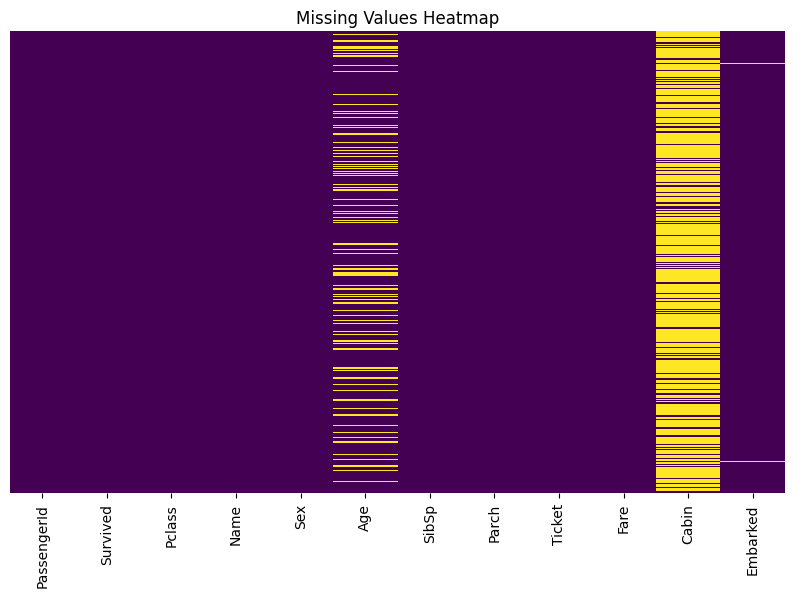

In [14]:
print("-Basic Information-")
print(df.info())

print("\n-Missing Values-")
print(df.isnull().sum())

#Visualizing missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

-Survival Distribution-
Survived
0    549
1    342
Name: count, dtype: int64

Survival Percentage:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


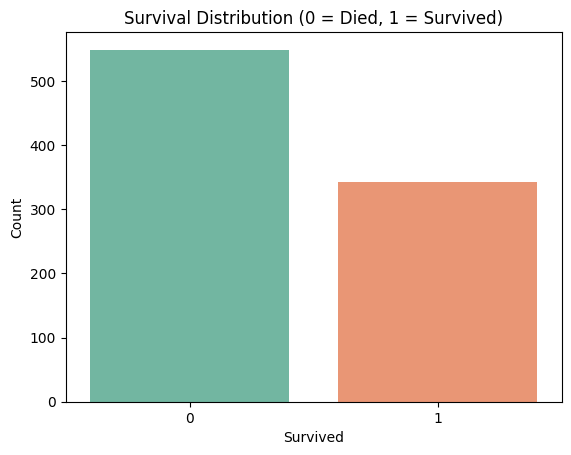

In [15]:
print("-Survival Distribution-")
print(df['Survived'].value_counts())
print("\nSurvival Percentage:")
print(round(df['Survived'].value_counts(normalize=True) * 100, 2))

sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Survival Distribution (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

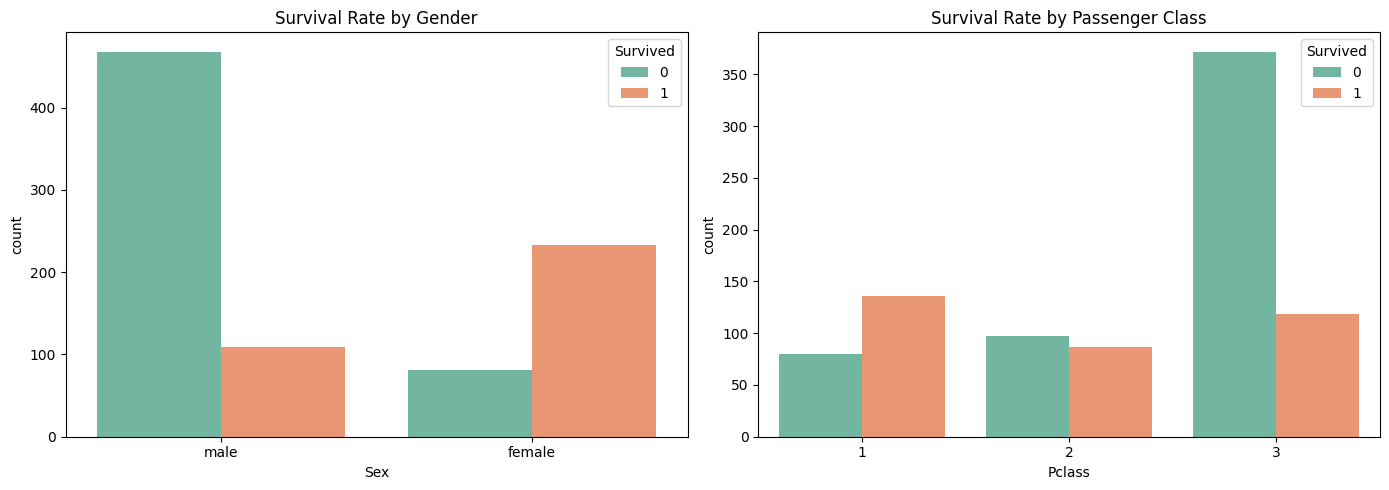

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Sex', hue='Survived', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Survival Rate by Gender')

sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Survival Rate by Passenger Class')

plt.tight_layout()
plt.show()

In [17]:
#Extract Title from Name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Group rare titles together
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major',
                                   'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

#Create Has_Cabin feature
df['Has_Cabin'] = df['Cabin'].apply(lambda x: 0 if pd.isnull(x) else 1)

#Create Family features
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

#Drop columns that are not useful
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

#Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

print("Feature Engineering Completed!")
print("Final Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMissing Values After Cleaning:\n", df.isnull().sum())
print("\nFirst 5 rows preview:")
print(df.head())

Feature Engineering Completed!
Final Shape: (891, 12)
Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'Has_Cabin', 'FamilySize', 'IsAlone']

Missing Values After Cleaning:
 Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
Title         0
Has_Cabin     0
FamilySize    0
IsAlone       0
dtype: int64

First 5 rows preview:
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked Title  \
0         0       3    male  22.0      1      0   7.2500        S    Mr   
1         1       1  female  38.0      1      0  71.2833        C   Mrs   
2         1       3  female  26.0      0      0   7.9250        S  Miss   
3         1       1  female  35.0      1      0  53.1000        S   Mrs   
4         0       3    male  35.0      0      0   8.0500        S    Mr   

   Has_Cabin  FamilySize  IsAlone  
0          0           2        0  
1          1           2       

In [18]:
#Encoding

from sklearn.preprocessing import LabelEncoder
le_sex = LabelEncoder()
le_embarked = LabelEncoder()
le_title = LabelEncoder()

df['Sex'] = le_sex.fit_transform(df['Sex'])
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])
df['Title'] = le_title.fit_transform(df['Title'])

# Final verification
print("Encoding Completed!")
print("Final Dataset Shape:", df.shape)
print("\nColumns after encoding:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values (Final Check):\n", df.isnull().sum())

print("\nFirst 5 rows of final dataset:")
print(df.head())

Encoding Completed!
Final Dataset Shape: (891, 12)

Columns after encoding: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'Has_Cabin', 'FamilySize', 'IsAlone']

Data Types:
 Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked        int64
Title           int64
Has_Cabin       int64
FamilySize      int64
IsAlone         int64
dtype: object

Missing Values (Final Check):
 Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
Title         0
Has_Cabin     0
FamilySize    0
IsAlone       0
dtype: int64

First 5 rows of final dataset:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Title  \
0         0       3    1  22.0      1      0   7.2500         2      2   
1         1       1    0  38.0      1      0  71.2833         0      3   
2         1       3

In [20]:
#train-test-split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print("Data Split Completed!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Feature Scaling
scaler = StandardScaler()

#Scaling only numerical columns
num_cols = ['Age', 'Fare', 'FamilySize']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("\nFeature Scaling Completed!")
print("Scaled features shape (train):", X_train_scaled.shape)

Data Split Completed!
Training samples: 712
Testing samples: 179

Feature Scaling Completed!
Scaled features shape (train): (712, 11)


In [22]:
#training both models

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model 1: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5
)

rf_model.fit(X_train, y_train)   # No scaling needed for tree models

# Model 2: XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    max_depth=5
)

xgb_model.fit(X_train, y_train)

print("Both Models Trained Successfully!")
print("Random Forest and XGBoost are ready for evaluation.")

Both Models Trained Successfully!
Random Forest and XGBoost are ready for evaluation.



==================== Random Forest Performance ====================
Accuracy  : 0.8212
Precision : 0.7846
Recall    : 0.7391
F1 Score  : 0.7612

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       110
           1       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



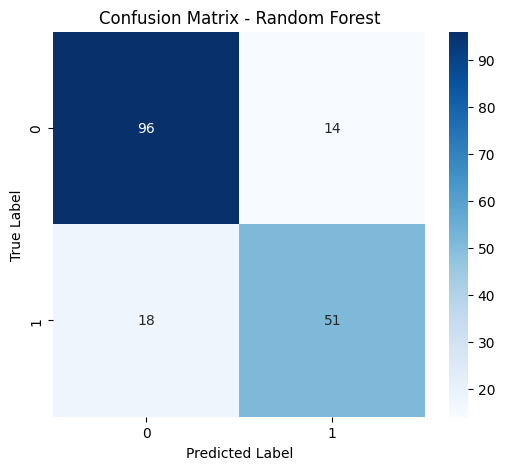


==================== XGBoost Performance ====================
Accuracy  : 0.7989
Precision : 0.7391
Recall    : 0.7391
F1 Score  : 0.7391

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



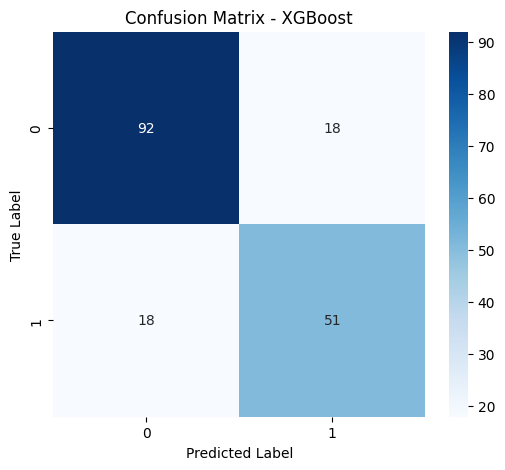

In [23]:
#model evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n{'='*20} {model_name} Performance {'='*20}")
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Evaluate both models
evaluate_model(rf_model, X_test, y_test, "Random Forest")
evaluate_model(xgb_model, X_test, y_test, "XGBoost")

In [24]:
#model selection and saving

print("-FINAL MODEL COMPARISON-\n")
print(f"Random Forest Accuracy : {accuracy_score(y_test, rf_model.predict(X_test)):.4f}")
print(f"XGBoost Accuracy       : {accuracy_score(y_test, xgb_model.predict(X_test)):.4f}")

# Select the best model
if accuracy_score(y_test, rf_model.predict(X_test)) > accuracy_score(y_test, xgb_model.predict(X_test)):
    best_model = rf_model
    best_model_name = "Random Forest"
else:
    best_model = xgb_model
    best_model_name = "XGBoost"

print(f"\n🏆 Best Model Selected: **{best_model_name}**")

# Save the best model
import joblib
joblib.dump(best_model, 'titanic_survival_model.pkl')

print(f"\n✅ Best model ({best_model_name}) saved as 'titanic_survival_model.pkl'")
print("You can now download this file from the Colab files panel.")

# Optional: Save the feature columns for future use
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')
print("Feature columns list also saved.")

-FINAL MODEL COMPARISON-

Random Forest Accuracy : 0.8212
XGBoost Accuracy       : 0.7989

🏆 Best Model Selected: **Random Forest**

✅ Best model (Random Forest) saved as 'titanic_survival_model.pkl'
You can now download this file from the Colab files panel.
Feature columns list also saved.


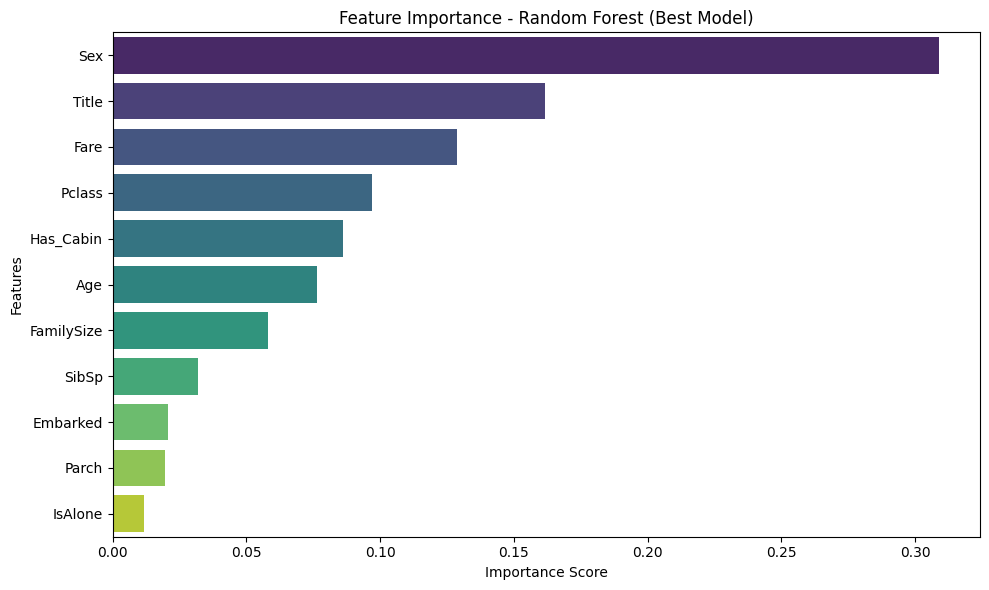

Top 5 Most Important Features:
Sex          0.308832
Title        0.161563
Fare         0.128639
Pclass       0.096797
Has_Cabin    0.086122
dtype: float64


In [25]:
#feature importance

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importance - Random Forest (Best Model)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print top features
print("Top 5 Most Important Features:")
print(feat_imp.head(5))